In [ ]:
import numpy as np
from copy import deepcopy
import matplotlib.pyplot as plt
from matplotlib import cm
from matplotlib.colors import Normalize

from pypower.api import runopf, ppoption
from pypower.idx_gen import PG, QG, PMIN, PMAX

# -----------------------------
# WB5 case in Python / PYPOWER format
# -----------------------------
def make_WB5():
    mpc = {
        "version": "2",
        "baseMVA": 100.0,
        "bus": np.array([
            [1, 3,   0,   0, 0, 0, 1, 1.0,    0,   345, 1, 1.05, 0.95],
            [2, 1, 130,  20, 0, 0, 1, 1.0,  -10,   345, 1, 1.05, 0.95],
            [3, 1, 130,  20, 0, 0, 1, 1.0,  -20,   345, 1, 1.05, 0.95],
            [4, 1,  65,  10, 0, 0, 1, 1.0, -135,   345, 1, 1.05, 0.95],
            [5, 2,   0,   0, 0, 0, 1, 1.0, -140,   345, 1, 1.05, 0.95],
        ], dtype=float),
        "gen": np.array([
            [1, 500, 50, 1800, -30, 1, 100, 1, 5000, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
            [5,   0,  0, 1800, -30, 1, 100, 1, 5000, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
        ], dtype=float),
        "branch": np.array([
            [1, 2, 0.04, 0.09, 0.00, 2500, 2500, 2500, 0, 0, 1, -360, 360],
            [1, 3, 0.05, 0.10, 0.00, 2500, 2500, 2500, 0, 0, 1, -360, 360],
            [2, 4, 0.55, 0.90, 0.45, 2500, 2500, 2500, 0, 0, 1, -360, 360],
            [3, 5, 0.55, 0.90, 0.45, 2500, 2500, 2500, 0, 0, 1, -360, 360],
            [4, 5, 0.06, 0.10, 0.00, 2500, 2500, 2500, 0, 0, 1, -360, 360],
            [2, 3, 0.07, 0.09, 0.00, 2500, 2500, 2500, 0, 0, 1, -360, 360],
        ], dtype=float),
        "areas": np.array([[1, 5]], dtype=float),
        "gencost": np.array([
            [2, 2, 0, 3, 0, 4.00, 0],
            [2, 2, 0, 3, 0, 1.00, 0],
        ], dtype=float),
    }
    return mpc

mpc0 = make_WB5()

ppopt = ppoption(VERBOSE=0, OUT_ALL=0)
res = runopf(mpc0, ppopt)
print("OPF success:", bool(res["success"]))
print("Objective:", res["f"])

OPF success: True
Objective: 1082.3325036854237


C:\Users\firda\AppData\Local\Temp\ipykernel_9332\1659207209.py:52: RuntimeWarning: All-NaN slice encountered
  norm = Normalize(vmin=np.nanmin(C), vmax=np.nanmax(C))


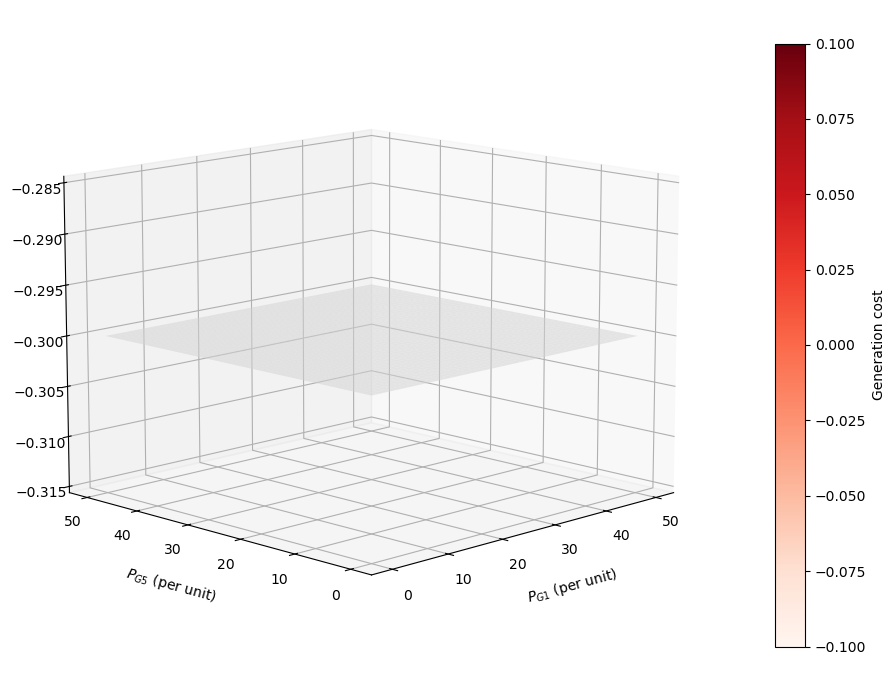

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import cm
from matplotlib.colors import Normalize
from copy import deepcopy

from pypower.api import runopf, ppoption
from pypower.idx_gen import PG, QG, PMIN, PMAX

def solve_fixed_pg(pg1_mw, pg5_mw, base_case, ppopt):
    case = deepcopy(base_case)

    # Fix generator active powers by setting Pmin = Pmax = Pg
    case["gen"][0, PG] = pg1_mw
    case["gen"][0, PMIN] = pg1_mw
    case["gen"][0, PMAX] = pg1_mw

    case["gen"][1, PG] = pg5_mw
    case["gen"][1, PMIN] = pg5_mw
    case["gen"][1, PMAX] = pg5_mw

    r = runopf(case, ppopt)
    if not r["success"]:
        return None

    qg5_pu = r["gen"][1, QG] / r["baseMVA"]
    cost = r["f"]
    return qg5_pu, cost

# Grid in MW
Pg1_vals = np.linspace(0, 5000, 45)
Pg5_vals = np.linspace(0, 5000, 45)

Z = np.full((len(Pg5_vals), len(Pg1_vals)), np.nan)   # Q_G5 in pu
C = np.full((len(Pg5_vals), len(Pg1_vals)), np.nan)   # objective cost

for i, pg5 in enumerate(Pg5_vals):
    for j, pg1 in enumerate(Pg1_vals):
        out = solve_fixed_pg(pg1, pg5, mpc0, ppopt)
        if out is not None:
            qg5_pu, cost = out
            Z[i, j] = qg5_pu
            C[i, j] = cost

# Mesh for plotting
P1g, P5g = np.meshgrid(Pg1_vals / mpc0["baseMVA"], Pg5_vals / mpc0["baseMVA"])

fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection="3d")

# Feasible surface colored by cost
norm = Normalize(vmin=np.nanmin(C), vmax=np.nanmax(C))
facecolors = cm.Reds(norm(C))
facecolors[np.isnan(Z)] = (0, 0, 0, 0)

surf = ax.plot_surface(
    P1g, P5g, Z,
    facecolors=facecolors,
    linewidth=0,
    antialiased=True,
    shade=False
)

# Gray lower reactive power limit plane, like the paper
Q_plane = -0.30 * np.ones_like(Z)
ax.plot_surface(
    P1g, P5g, Q_plane,
    color="lightgray",
    alpha=0.55,
    linewidth=0,
    shade=False
)

# Example markers; replace with your actual global/local optimum points
# ax.scatter(pg1_star, pg5_star, qg5_star, marker='*', s=220, color='limegreen', edgecolor='k')
# ax.scatter(pg1_local, pg5_local, qg5_local, marker='v', s=120, color='royalblue', edgecolor='k')

ax.set_xlabel(r"$P_{G1}$ (per unit)", labelpad=12)
ax.set_ylabel(r"$P_{G5}$ (per unit)", labelpad=12)
ax.set_zlabel(r"$Q_{G5}$ (per unit)", labelpad=12)
ax.view_init(elev=12, azim=-135)

mappable = cm.ScalarMappable(norm=norm, cmap=cm.Reds)
mappable.set_array([])
cbar = fig.colorbar(mappable, ax=ax, pad=0.08, shrink=0.9)
cbar.set_label("Generation cost")
plt.tight_layout()
plt.show()

In [ ]:
# =============================================================================
# WB5 Five-Bus OPF — Feasible Space Visualization
# Reproduces Fig. 3 from Molzahn (2017) / Bukhsh et al. (2013)
#
# Approach:
#   • Discretize (P_G5, V_G5, V_G1) — the generator "control" variables
#   • Solve the AC power flow at every grid point (multiple starting points
#     to capture both disconnected components)
#   • Keep points that satisfy all OPF constraints
#   • Plot the feasible set in (P_G1, P_G5, Q_G5) space, coloured by cost
# =============================================================================

# ── Cell 1 · Imports ──────────────────────────────────────────────────────────
import numpy as np
from scipy.optimize import fsolve
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D          # needed for 3-D axes
import warnings
warnings.filterwarnings("ignore")

# ── Cell 2 · WB5 System Data (per unit, 100 MVA base) ────────────────────────
#
# Bus layout (0-indexed):
#   Bus 0  →  Slack / Generator G1
#   Bus 1  →  PQ load  (1.30 pu real, 0.20 pu reactive)
#   Bus 2  →  PQ load  (1.30 pu real, 0.20 pu reactive)
#   Bus 3  →  PQ load  (0.65 pu real, 0.10 pu reactive)
#   Bus 4  →  PV  / Generator G5  (no load)
#
# Generator limits  (same for both):
#   Q_min = −0.30 pu,  Q_max = 18.0 pu  (from Qmin=−30 / Qmax=1800 MVAr)
#
# Cost:  400·P_G1 + 100·P_G5  [$/h]
#        (c1 = 4 $/MWh × 100 MVA base = 400; c1 = 1 $/MWh → 100)

n = 5

# Branches: (from_bus, to_bus, R_pu, X_pu, B_total_pu)
branch_data = [
    (0, 1, 0.04, 0.09, 0.00),
    (0, 2, 0.05, 0.10, 0.00),
    (1, 3, 0.55, 0.90, 0.45),
    (2, 4, 0.55, 0.90, 0.45),
    (3, 4, 0.06, 0.10, 0.00),
    (1, 2, 0.07, 0.09, 0.00),
]

# Build Y-bus
Y = np.zeros((n, n), dtype=complex)
for (i, j, r, x, bc) in branch_data:
    ys  = 1.0 / (r + 1j * x)   # series admittance
    ysh = 1j * bc / 2.0         # half-line charging susceptance
    Y[i, i] += ys + ysh;  Y[j, j] += ys + ysh
    Y[i, j] -= ys;         Y[j, i] -= ys

G, B = Y.real, Y.imag

# Load demands
Pd = np.array([0.00, 1.30, 1.30, 0.65, 0.00])   # pu
Qd = np.array([0.00, 0.20, 0.20, 0.10, 0.00])   # pu

# Bounds
V_MIN,  V_MAX  = 0.95, 1.05
QG_MIN, QG_MAX = -0.30, 18.0

# Known OPF solutions (from Molzahn 2017, Table in Section V)
GLOBAL_SOL = (1.81, 2.21, -0.30)   # (P_G1, P_G5, Q_G5)  pu
LOCAL_SOL  = (2.46, 0.98, -0.30)

# ── Cell 3 · Power Flow Solver ────────────────────────────────────────────────
def bus_powers(Vm, th):
    """Vectorised active/reactive power injections at all buses."""
    d = th[:, None] - th[None, :]
    P = (Vm[:, None] * Vm[None, :] * (G * np.cos(d) + B * np.sin(d))).sum(axis=1)
    Q = (Vm[:, None] * Vm[None, :] * (G * np.sin(d) - B * np.cos(d))).sum(axis=1)
    return P, Q


def solve_pf(P_G5, V_G1, V_G5, x0):
    """
    Newton–Raphson power flow for WB5.

    Parameters
    ----------
    P_G5 : float  — active power injection of G5 (bus 4), pu
    V_G1 : float  — voltage magnitude at slack bus (bus 0), pu
    V_G5 : float  — voltage magnitude at PV bus (bus 4), pu
    x0   : array  — initial guess [θ1, θ2, θ3, θ4, V1, V2, V3]

    Returns
    -------
    dict with P_G1, Q_G1, Q_G5, Vm  —  or None if no convergence.
    """
    # Net power specs at non-slack buses (buses 1, 2, 3, 4)
    P_spec = np.array([-Pd[1], -Pd[2], -Pd[3], P_G5])
    Q_spec = np.array([-Qd[1], -Qd[2], -Qd[3]])

    def residuals(x):
        th = np.array([0., x[0], x[1], x[2], x[3]])
        Vm = np.array([V_G1, x[4], x[5], x[6], V_G5])
        P, Q = bus_powers(Vm, th)
        return [
            P_spec[0] - P[1], P_spec[1] - P[2],
            P_spec[2] - P[3], P_spec[3] - P[4],
            Q_spec[0] - Q[1], Q_spec[1] - Q[2], Q_spec[2] - Q[3],
        ]

    sol, info, ier, _ = fsolve(residuals, x0, full_output=True, xtol=1e-10)
    if ier != 1 or np.max(np.abs(info["fvec"])) > 1e-6:
        return None

    th = np.array([0., sol[0], sol[1], sol[2], sol[3]])
    Vm = np.array([V_G1, sol[4], sol[5], sol[6], V_G5])
    P, Q = bus_powers(Vm, th)

    return dict(P_G1=P[0], Q_G1=Q[0], Q_G5=Q[4], Vm=Vm)


# ── Cell 4 · Grid Sweep ───────────────────────────────────────────────────────
#
# We discretise the generator "setpoints" and voltage magnitudes,
# solve the power flow at each point, and keep feasible solutions.
#
# Grid resolution — feel free to reduce step sizes for a finer plot
# (finer = longer runtime; ~0.05 / 0.005 gives a smoother surface).

P5_vals = np.arange(0.0,  4.01, 0.10)    # 41 values
V5_vals = np.arange(0.95, 1.051, 0.01)   # 11 values
V1_vals = np.arange(0.95, 1.051, 0.01)   # 11 values  → 41×11×11 = 4 951 grid pts

# Multiple starting points — essential to capture BOTH disconnected components.
# The component containing the local optimum needs reversed/large angle starts.
X0_LIST = [
    [ 0.0,  0.0,  0.0,  0.0,  1.00, 1.00, 1.00],   # flat start
    [-0.1, -0.2, -0.3, -0.4,  0.97, 0.97, 0.97],
    [ 0.1,  0.2,  0.1,  0.2,  1.02, 1.02, 1.02],
    [ 0.0,  0.0,  0.0, -1.0,  1.00, 1.00, 1.00],   # large negative θ₄
    [ 0.0,  0.0,  0.0,  1.0,  1.00, 1.00, 1.00],   # large positive  θ₄
    [-0.5, -0.5, -0.3, -1.5,  0.95, 0.95, 0.95],
    [ 0.5,  0.5,  0.3,  0.5,  1.05, 1.05, 1.05],
]

pts = []   # feasible points: [P_G1, P_G5, Q_G5, cost]

n_grid = len(P5_vals) * len(V5_vals) * len(V1_vals)
print(f"Grid: {len(P5_vals)} × {len(V5_vals)} × {len(V1_vals)} = {n_grid:,} points")
print(f"Starts per point: {len(X0_LIST)}  →  {n_grid*len(X0_LIST):,} total solves")
print("This typically takes 3–8 minutes on a modern laptop.\n")

for ip, P5 in enumerate(P5_vals):
    for V5 in V5_vals:
        for V1 in V1_vals:
            seen = set()
            for x0 in X0_LIST:
                res = solve_pf(P5, V1, V5, x0)
                if res is None:
                    continue

                P1, Q1, Q5 = res["P_G1"], res["Q_G1"], res["Q_G5"]
                Vm = res["Vm"]

                # ── de-duplicate (same solution from different starts) ────────
                key = tuple(np.round([P1, Q1, Q5, *Vm], 2))
                if key in seen:
                    continue
                seen.add(key)

                # ── feasibility checks ───────────────────────────────────────
                EPS = 1e-4
                if P1 < -EPS:
                    continue
                if not (QG_MIN - EPS <= Q1 <= QG_MAX + EPS):
                    continue
                if not (QG_MIN - EPS <= Q5 <= QG_MAX + EPS):
                    continue
                if not all(V_MIN - EPS <= v <= V_MAX + EPS for v in Vm):
                    continue

                cost = 400.0 * P1 + 100.0 * P5
                pts.append([P1, P5, Q5, cost])

    if (ip + 1) % 10 == 0 or ip == len(P5_vals) - 1:
        print(f"  [{ip+1:2d}/{len(P5_vals)}]  P_G5 = {P5:.2f} pu  "
              f"→  {len(pts):5d} feasible points collected")

pts = np.array(pts)
print(f"\nDone.  Total feasible points: {len(pts):,}")


# ── Cell 5 · 3-D Plot ─────────────────────────────────────────────────────────
fig = plt.figure(figsize=(13, 9))
ax  = fig.add_subplot(111, projection="3d")

P1_p   = pts[:, 0]
P5_p   = pts[:, 1]
Q5_p   = pts[:, 2]
cost_p = pts[:, 3]

# ── feasible-space scatter (coloured by generation cost) ─────────────────────
sc = ax.scatter(
    P5_p, P1_p, Q5_p,
    c=cost_p, cmap="Reds",
    vmin=cost_p.min(), vmax=cost_p.max(),
    s=6, alpha=0.55, linewidths=0,
)

# ── gray plane  Q_G5 = −0.30 pu ──────────────────────────────────────────────
# This is the reactive-power lower limit that splits the feasible space.
pg5g, pg1g = np.meshgrid(np.linspace(-2, 4, 30), np.linspace(-0.5, 5.5, 30))
ax.plot_surface(pg5g, pg1g, np.full_like(pg5g, QG_MIN),
                alpha=0.18, color="gray", zorder=0)

# ── known OPF solutions ───────────────────────────────────────────────────────
gP1, gP5, gQ5 = GLOBAL_SOL
lP1, lP5, lQ5 = LOCAL_SOL

ax.scatter([gP5], [gP1], [gQ5],
           c="lime", s=350, marker="*",
           zorder=10, depthshade=False, label="Global optimum")
ax.scatter([lP5], [lP1], [lQ5],
           c="dodgerblue", s=200, marker="v",
           zorder=10, depthshade=False,
           label=f"Local optimum  (+14.3 % cost)")

# ── colorbar ──────────────────────────────────────────────────────────────────
cbar = plt.colorbar(sc, ax=ax, shrink=0.55, pad=0.10, aspect=20)
cbar.set_label("Generation Cost ($/h)", fontsize=11)
cbar.ax.yaxis.set_major_formatter(
    plt.FuncFormatter(lambda x, _: f"${x:,.0f}"))

# ── labels & formatting ───────────────────────────────────────────────────────
ax.set_xlabel("$P_{G5}$ (per unit)", labelpad=10, fontsize=12)
ax.set_ylabel("$P_{G1}$ (per unit)", labelpad=10, fontsize=12)
ax.set_zlabel("$Q_{G5}$ (per unit)", labelpad=10, fontsize=12)

ax.set_title(
    "Feasible Space of the WB5 Five-Bus OPF Problem\n"
    r"Gray plane: $Q_{G5} \geq -0.30$ pu  (splits space into two disconnected components)",
    fontsize=11, pad=15,
)

ax.set_xlim([-1, 4])
ax.set_ylim([ 0, 5])
ax.set_zlim([-0.55, 0.8])

ax.view_init(elev=20, azim=-55)
ax.legend(loc="upper left", fontsize=10, framealpha=0.85)

plt.tight_layout()
plt.savefig("WB5_feasible_space.png", dpi=150, bbox_inches="tight")
plt.show()
print("Figure saved → WB5_feasible_space.png")

Grid: 41 × 11 × 11 = 4,961 points
Starts per point: 7  →  34,727 total solves
This typically takes 3–8 minutes on a modern laptop.

  [10/41]  P_G5 = 0.90 pu  →    195 feasible points collected
  [20/41]  P_G5 = 1.90 pu  →    195 feasible points collected
  [30/41]  P_G5 = 2.90 pu  →    196 feasible points collected
